In [1]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold

from sklearn.metrics import mean_squared_error

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
import random
import numpy as np
import torch

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behavior
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(0)

In [3]:
bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [4]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [5]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [6]:
# BUILD FNO DATASET FROM RAW Qdlin CURVES
# Input per battery: ΔQdlin_k(V) = Qdlin_k(V) - Qdlin_10(V)
# Uses only cycles 20, 30, 40, ..., 100
# Output per battery: log10(cycle_life)

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

REF_IDX = 9        # cycle 10, zero-indexed
CYCLE_IDXS = list(range(19, 100, 5))   # cycles 20, 30, ..., 100
N_CYCLES = len(CYCLE_IDXS)
N_VOLTAGE = 1000

print("Using cycle numbers:", [i + 1 for i in CYCLE_IDXS])
print("N_CYCLES:", N_CYCLES)

def get_qdlin_1000(cyc):
    q = np.asarray(cyc["Qdlin"], dtype=float).squeeze()

    if q.shape[0] != N_VOLTAGE:
        return None

    return q

def build_fno_arrays(df, split_name):
    X_list = []
    y_list = []
    battery_ids = []

    for _, row in df.iterrows():

        cycles_dict = row["cycles"]

        # Need reference cycle 10
        if str(REF_IDX) not in cycles_dict:
            print(f"Skipping {row['battery_id']} in {split_name}: missing reference cycle 10")
            continue

        q_ref = get_qdlin_1000(cycles_dict[str(REF_IDX)])

        if q_ref is None:
            print(f"Skipping {row['battery_id']} in {split_name}: bad reference Qdlin shape")
            continue

        battery_tensor = []
        valid = True

        for cyc_idx in CYCLE_IDXS:

            if str(cyc_idx) not in cycles_dict:
                valid = False
                break

            q = get_qdlin_1000(cycles_dict[str(cyc_idx)])

            if q is None:
                valid = False
                break

            dq = q - q_ref
            battery_tensor.append(dq)

        if not valid:
            print(f"Skipping {row['battery_id']} in {split_name}: missing/bad Qdlin shape")
            continue

        # Shape: [selected_cycles, voltage]
        battery_tensor = np.stack(battery_tensor, axis=0)

        # Add channel dimension: [selected_cycles, voltage, channels]
        battery_tensor = battery_tensor[..., None]

        X_list.append(battery_tensor)
        y_list.append(np.log10(row["cycle_life"]))
        battery_ids.append(row["battery_id"])

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    print(split_name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, battery_ids


X_train, y_train, train_ids = build_fno_arrays(train_df, "train")
X_primary, y_primary, primary_ids = build_fno_arrays(primary_test_df, "primary_test")
X_secondary, y_secondary, secondary_ids = build_fno_arrays(secondary_test_df, "secondary_test")

Using cycle numbers: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
N_CYCLES: 17
train
X shape: (41, 17, 1000, 1)
y shape: (41, 1)
primary_test
X shape: (43, 17, 1000, 1)
y shape: (43, 1)
secondary_test
X shape: (40, 17, 1000, 1)
y shape: (40, 1)


In [7]:
# NORMALIZE X USING TRAIN SET ONLY

X_mean = X_train.mean()
X_std = X_train.std() + 1e-8

X_train_n = (X_train - X_mean) / X_std
X_primary_n = (X_primary - X_mean) / X_std
X_secondary_n = (X_secondary - X_mean) / X_std

# Normalize target too
y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_n = (y_train - y_mean) / y_std
y_primary_n = (y_primary - y_mean) / y_std
y_secondary_n = (y_secondary - y_mean) / y_std

# Convert to torch
X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
y_train_t = torch.tensor(y_train_n, dtype=torch.float32)

X_primary_t = torch.tensor(X_primary_n, dtype=torch.float32)
y_primary_t = torch.tensor(y_primary_n, dtype=torch.float32)

X_secondary_t = torch.tensor(X_secondary_n, dtype=torch.float32)
y_secondary_t = torch.tensor(y_secondary_n, dtype=torch.float32)

g = torch.Generator()
g.manual_seed(0)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=8,
    shuffle=True,
    generator=g
)

In [8]:
# SMALL 2D FNO MODEL FOR CYCLE LIFE REGRESSION

import torch
import torch.nn as nn
import torch.nn.functional as F

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_cycle, modes_voltage):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_cycle = modes_cycle
        self.modes_voltage = modes_voltage

        scale = 1 / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes_cycle,
                modes_voltage,
                dtype=torch.cfloat
            )
        )

    def compl_mul2d(self, input, weights):
        # input:   [batch, in_channels, x, y]
        # weights: [in_channels, out_channels, x, y]
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]

        # Fourier transform
        x_ft = torch.fft.rfft2(x)

        # Output in Fourier domain
        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-2),
            x.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        # Keep only low-frequency modes
        out_ft[:, :, :self.modes_cycle, :self.modes_voltage] = self.compl_mul2d(
            x_ft[:, :, :self.modes_cycle, :self.modes_voltage],
            self.weights
        )

        # Back to physical domain
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        return x


class FNO2dBattery(nn.Module):
    def __init__(self, in_channels=1, width=24, modes_cycle=12, modes_voltage=32):
        super().__init__()

        self.width = width

        # Lift input channel to width channels
        self.fc0 = nn.Linear(in_channels + 2, width)

        self.conv0 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv1 = SpectralConv2d(width, width, modes_cycle, modes_voltage)
        self.conv2 = SpectralConv2d(width, width, modes_cycle, modes_voltage)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)

        self.regressor = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

    def get_grid(self, batchsize, size_cycle, size_voltage, device):
        cycle_grid = torch.linspace(0, 1, size_cycle, device=device)
        voltage_grid = torch.linspace(0, 1, size_voltage, device=device)

        cycle_grid = cycle_grid.reshape(1, size_cycle, 1, 1).repeat(batchsize, 1, size_voltage, 1)
        voltage_grid = voltage_grid.reshape(1, 1, size_voltage, 1).repeat(batchsize, size_cycle, 1, 1)

        return torch.cat([cycle_grid, voltage_grid], dim=-1)

    def forward(self, x):
        # x shape: [batch, cycles, voltage, channels]

        batchsize, size_cycle, size_voltage, channels = x.shape

        grid = self.get_grid(batchsize, size_cycle, size_voltage, x.device)

        # Add coordinate grid
        x = torch.cat([x, grid], dim=-1)

        # Lift
        x = self.fc0(x)

        # [batch, cycles, voltage, width] -> [batch, width, cycles, voltage]
        x = x.permute(0, 3, 1, 2)

        x = F.gelu(self.conv0(x) + self.w0(x))
        x = F.gelu(self.conv1(x) + self.w1(x))
        x = F.gelu(self.conv2(x) + self.w2(x))

        # Global average pooling over cycle and voltage dimensions
        x = x.mean(dim=(-2, -1))

        # Predict normalized log10(cycle_life)
        out = self.regressor(x)

        return out

In [19]:
# TRAIN FNO MODEL

from sklearn.metrics import mean_squared_error
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

set_seed(0)

model = FNO2dBattery(
    in_channels=1,
    width=24,
    modes_cycle=10,
    modes_voltage=32
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

num_epochs = 1000

for epoch in range(num_epochs):
    model.train()
    losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    if epoch % 25 == 0:
        print(f"Epoch {epoch:4d} | Loss: {np.mean(losses):.6f}")

device: cuda
Epoch    0 | Loss: 0.874684
Epoch   25 | Loss: 0.203306
Epoch   50 | Loss: 0.077048
Epoch   75 | Loss: 0.073650
Epoch  100 | Loss: 0.034551
Epoch  125 | Loss: 0.014445
Epoch  150 | Loss: 0.035148
Epoch  175 | Loss: 0.011222
Epoch  200 | Loss: 0.013392
Epoch  225 | Loss: 0.007965
Epoch  250 | Loss: 0.008446
Epoch  275 | Loss: 0.016776
Epoch  300 | Loss: 0.006839
Epoch  325 | Loss: 0.008928
Epoch  350 | Loss: 0.008092
Epoch  375 | Loss: 0.008958
Epoch  400 | Loss: 0.004272
Epoch  425 | Loss: 0.007721
Epoch  450 | Loss: 0.005545
Epoch  475 | Loss: 0.004444
Epoch  500 | Loss: 0.004213
Epoch  525 | Loss: 0.010243
Epoch  550 | Loss: 0.016377
Epoch  575 | Loss: 0.011604
Epoch  600 | Loss: 0.012808
Epoch  625 | Loss: 0.005621
Epoch  650 | Loss: 0.008280
Epoch  675 | Loss: 0.004489
Epoch  700 | Loss: 0.004374
Epoch  725 | Loss: 0.008588
Epoch  750 | Loss: 0.001898
Epoch  775 | Loss: 0.002279
Epoch  800 | Loss: 0.006431
Epoch  825 | Loss: 0.001850
Epoch  850 | Loss: 0.002993
Epoch  

In [20]:
# EVALUATE FNO MODEL

def evaluate_fno(name, X_t, y_true_log, battery_ids):
    model.eval()

    with torch.no_grad():
        pred_n = model(X_t.to(device)).cpu().numpy()

    # unnormalize log10 prediction
    pred_log = pred_n * y_std + y_mean

    # convert log10(cycle life) -> cycle life
    pred_cycle_life = 10 ** pred_log.ravel()
    true_cycle_life = 10 ** y_true_log.ravel()

    rmse = np.sqrt(mean_squared_error(true_cycle_life, pred_cycle_life))
    mpe = np.mean(np.abs(pred_cycle_life - true_cycle_life) / true_cycle_life) * 100

    print(name)
    print(f"  RMSE cycles: {rmse:.2f}")
    print(f"  MPE: {mpe:.2f}%")

    results = pd.DataFrame({
        "battery_id": battery_ids,
        "true_cycle_life": true_cycle_life,
        "pred_cycle_life": pred_cycle_life,
        "abs_percent_error": np.abs(pred_cycle_life - true_cycle_life) / true_cycle_life * 100
    })

    return results


train_fno_results = evaluate_fno("Train", X_train_t, y_train, train_ids)
primary_fno_results = evaluate_fno("Primary test", X_primary_t, y_primary, primary_ids)
secondary_fno_results = evaluate_fno("Secondary test", X_secondary_t, y_secondary, secondary_ids)

display(train_fno_results)
display(primary_fno_results)
display(secondary_fno_results)

Train
  RMSE cycles: 8.05
  MPE: 0.93%
Primary test
  RMSE cycles: 89.79
  MPE: 10.94%
Secondary test
  RMSE cycles: 188.93
  MPE: 11.18%


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c1,2160.000244,2130.502930,1.365616
1,b1c3,1434.000244,1429.815063,0.291854
2,b1c5,1073.999756,1063.991577,0.931860
3,b1c7,869.999817,876.928284,0.796376
4,b1c11,788.000244,791.116699,0.395489
5,b1c15,718.999817,716.390381,0.362926
6,b1c17,856.999939,839.384460,2.055482
7,b1c19,788.000244,780.594604,0.939802
8,b1c21,558.999878,557.647583,0.241913
9,b1c24,1016.999817,1008.719360,0.814204


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c0,1852.000366,1856.558838,0.246138
1,b1c2,2236.999512,1935.077393,13.496744
2,b1c4,1709.000000,1569.475464,8.164104
3,b1c6,635.999878,735.211304,15.599283
4,b1c9,1053.999756,826.990906,21.537846
5,b1c14,879.999756,814.865784,7.401590
6,b1c16,862.000061,849.141602,1.491701
7,b1c18,690.999939,704.663757,1.977398
8,b1c20,533.999939,539.284241,0.989570
9,b1c23,1014.000000,949.370178,6.373750


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b3c0,1009.000122,1113.841797,10.390651
1,b3c1,1063.000244,1071.657471,0.814414
2,b3c3,1114.999878,918.664490,17.608557
3,b3c4,1047.999756,1023.769470,2.312051
4,b3c5,827.999878,914.592041,10.457993
5,b3c6,666.999878,543.504639,18.515032
6,b3c7,1835.999756,1369.100342,25.430256
7,b3c8,827.999878,898.144104,8.471526
8,b3c9,1039.000244,942.110901,9.325247
9,b3c10,1078.000000,1275.553223,18.325903


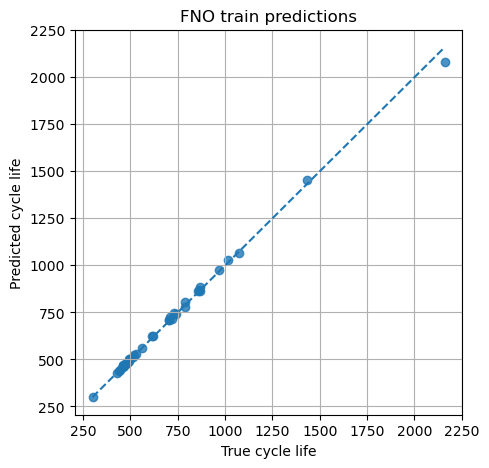

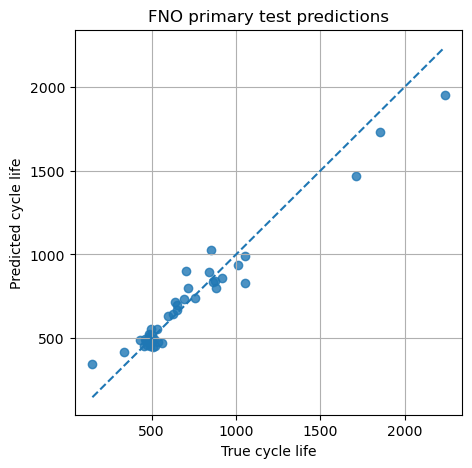

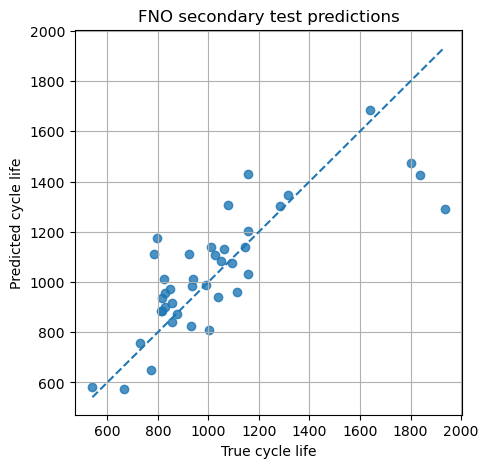

In [11]:
# PLOT PREDICTED VS TRUE CYCLE LIFE

import matplotlib.pyplot as plt

def plot_pred_vs_true(results, title):
    plt.figure(figsize=(5, 5))

    plt.scatter(results["true_cycle_life"], results["pred_cycle_life"], alpha=0.8)

    min_val = min(results["true_cycle_life"].min(), results["pred_cycle_life"].min())
    max_val = max(results["true_cycle_life"].max(), results["pred_cycle_life"].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("True cycle life")
    plt.ylabel("Predicted cycle life")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_pred_vs_true(train_fno_results, "FNO train predictions")
plot_pred_vs_true(primary_fno_results, "FNO primary test predictions")
plot_pred_vs_true(secondary_fno_results, "FNO secondary test predictions")